In [17]:
import numpy as np
import pandas as pd
import metpy.calc as mpcalc
from metpy.units import units
import  matplotlib.pyplot as plt

In [18]:
qc_fpath = "/home/aoi/research/bsod/sample/data/qc_data/1101322_qc.csv"
df = pd.read_csv(qc_fpath,index_col=0)
df.head()

,TimeUTC,DCnt,RE,FCnt,rcvFREQ,WM,WD,WS,Height,Xdistanc,...,FVH,FVL,FSP1,FSP2,FSP3,FSP4,N,Prs,Tmp,Hum
0,2024-06-18 01:30:04,0,4,1416,401.90347,1,0.0,0.00,2.0,0.0,...,327.71,350.09,0.0,2.05,221.75,0.0,9,1005.0,25.0,50.0
1,2024-06-18 01:30:05,2,4,1418,401.90347,1,180.0,0.00,-0.9,0.0,...,327.76,350.04,0.0,1.85,0.00,0.0,9,1005.3,19.2,87.8
2,2024-06-18 01:30:06,4,4,1420,401.90347,1,180.0,0.00,-2.1,0.0,...,327.76,350.04,0.0,2.05,221.82,0.0,9,1005.5,18.9,88.0
3,2024-06-18 01:30:07,6,4,1422,401.90347,1,180.0,0.00,-0.8,3.7,...,327.75,349.97,0.0,1.85,0.00,0.0,9,1005.3,18.9,88.2
4,2024-06-18 01:30:08,8,4,1424,401.90347,1,0.7,1.18,3.7,3.7,...,327.75,349.97,0.0,2.05,221.93,0.0,9,1004.8,18.8,88.5


In [19]:
# remove records observed above the maximum height
print(len(df))
max_z_idx = df["Height"].idxmax()
df = df.loc[:max_z_idx].reset_index(drop=True)
print(len(df))
# remove dessicated records
df["dz"] = df["Height"].diff().fillna(0)
df = df[df["dz"]>0]
print(len(df))

1467
1182
1179


In [20]:
df.columns

Index(['TimeUTC', 'DCnt', 'RE', 'FCnt', 'rcvFREQ', 'WM', 'WD', 'WS', 'Height',
       'Xdistanc', 'Ydistanc', 'HDP', 'PDP', 'GeodetLat', 'GeodetLon', 'V',
       'FE', 'FRT', 'FTI', 'FVH', 'FVL', 'FSP1', 'FSP2', 'FSP3', 'FSP4', 'N',
       'Prs', 'Tmp', 'Hum', 'dz'],
      dtype='object')

In [21]:
# time
time_utc = pd.to_datetime(df["TimeUTC"])
time_jst = time_utc + pd.Timedelta(hours=9)

In [22]:
# location
lon = df["GeodetLon"].values*units("deg")
lat = df["GeodetLat"].values*units("deg")
x = df["Xdistanc"].values*units("m")
y = df["Ydistanc"].values*units("m")

In [23]:
# temperature
tmp = df["Tmp"].values*units("degC")

In [24]:
# elevation
z = df["Height"].values*units("m")
prs = df["Prs"].values*units("hPa")

In [25]:
# Humidity
rh = df["Hum"].values*units("percent")
dewpoint = mpcalc.dewpoint_from_relative_humidity(tmp, rh)
mixr = mpcalc.mixing_ratio_from_relative_humidity(prs, tmp,rh)
spc_hum = mpcalc.specific_humidity_from_mixing_ratio(mixr)

In [26]:
# wind
wd = df["WD"].values*units("deg")
ws = df["WS"].values*units("m/s")
u, v = mpcalc.wind_components(ws,wd)

In [27]:
pt = mpcalc.potential_temperature(prs, tmp)
ept = mpcalc.equivalent_potential_temperature(prs, tmp, dewpoint)

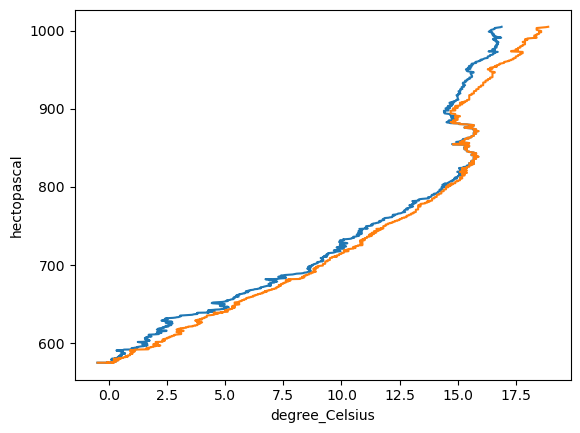

In [28]:
plt.plot(dewpoint,prs)
plt.plot(tmp,prs)
plt.show()